In [5]:
##### SI Figure 9: map of conservation scenario used

from pathlib import Path
import numpy as np
import rasterio
from rasterio.plot import show
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

In [6]:
##### Load data

# Get the current working directory
cd = Path.cwd().parent.parent

# priority raster
# 0 = not priority, 1 = in top 30%, not PA, 2 = in top 30%, already PA
biodiversity_with_PA = f"{cd}/Data/Clean/Priority_areas/biodiversity_with_PA.tif"

# country boundaries (simplified, for basemap context only)
country_simple = gpd.read_file(f"{cd}/Data/Clean/Geographies/country_geo.shp")

# Set file path to figure repo
fd = "/Users/carinamanitius/Library/CloudStorage/OneDrive-UniversityofVermont/Documents/OneDrive/Dissertation/Chapter 1/Figures/FINAL_FIGURES"

/var/folders/48/ky2jtbmj31bfj15cr5gq480w0000gn/T/ipykernel_11562/2878527667.py:22: RuntimeWarning: invalid value encountered in cast
  bio_arr.astype(np.int8),


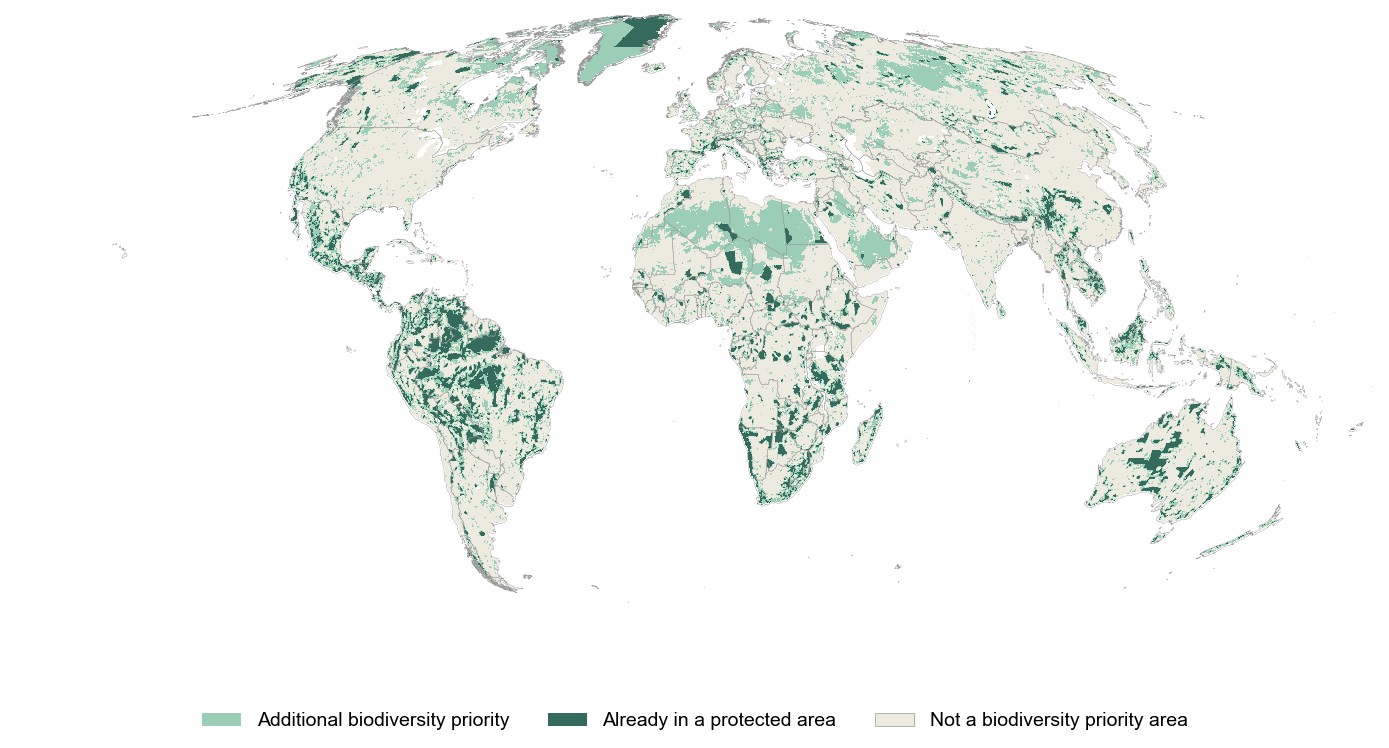

In [8]:
##### Figure: Map of biodiversity priority areas

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "Helvetica", "DejaVu Sans"]

def read_array(path, band=1):
    with rasterio.open(path) as src:
        arr = src.read(band).astype(float)
        nodata = src.nodata
        if nodata is not None:
            arr[arr == nodata] = np.nan
    return arr
 
 
##### Map of priority areas
 
bio_arr = read_array(biodiversity_with_PA)
 
map_class = np.where(
    np.isnan(bio_arr),
    -1,
    bio_arr.astype(np.int8),
)
 
masked_map = np.ma.masked_where(map_class == -1, map_class)
 
# A simple green palette for the biodiversity-only scenario
map_colors = [
    "#EDEAE0",  # 0 — not priority
    "#9BCDB7",  # 1 — additional priority
    "#356B5D",  # 2 — already in PA
]
 
cmap = mcolors.ListedColormap(map_colors)
norm = mcolors.BoundaryNorm(
    [-0.5, 0.5, 1.5, 2.5],
    cmap.N,
)
 
# Match country boundaries to raster CRS
with rasterio.open(biodiversity_with_PA) as src:
    raster_transform = src.transform
    raster_crs = src.crs
 
country_ctx = (
    country_simple.to_crs(raster_crs)
    if country_simple.crs != raster_crs
    else country_simple
)
 
# Plot
fig, ax = plt.subplots(figsize=(14, 8))
 
# White background
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
 
country_ctx.boundary.plot(
    ax=ax,
    color="#999999",
    linewidth=0.3,
    zorder=2,
)
 
show(
    masked_map,
    transform=raster_transform,
    ax=ax,
    cmap=cmap,
    norm=norm,
    zorder=1,
)
 
ax.set_axis_off()
 
legend_elements = [
    Patch(
        facecolor=map_colors[1],
        edgecolor="none",
        label="Additional biodiversity priority",
    ),
    Patch(
        facecolor=map_colors[2],
        edgecolor="none",
        label="Already in a protected area",
    ),
    Patch(
        facecolor=map_colors[0],
        edgecolor="#999999",
        linewidth=0.5,
        label="Not a biodiversity priority area",
    ),
]
 
ax.legend(
    handles=legend_elements,
    loc="upper center",
    frameon=False,
    fontsize=14,
    bbox_to_anchor=(0.5, -0.02),
    ncol=3,
)
 
plt.tight_layout()
plt.savefig(
    f"{fd}/SI_fig_9_biodiversity_priority_map.tiff",
    dpi=300,
    bbox_inches="tight",
    pil_kwargs={"compression": "tiff_lzw"},
)
plt.show()